<a href="https://colab.research.google.com/github/jhasu0202/citrus-disease-detection/blob/main/Citrus_ResNet50_CBAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Citrus Leaf Disease — ResNet50 + CBAM (clean rebuild)
This notebook picks up cleanly: mounts Drive, rebuilds the ResNet50+CBAM model, trains it (frozen backbone), evaluates it, then fine-tunes the top layers for a further accuracy boost.

Run cells top to bottom, in order, without skipping.

### 1. Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Imports and CBAM (attention) building blocks

In [2]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.layers import (GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Dropout,
                                       Reshape, Multiply, Concatenate, Conv2D, Add, Activation, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


def channel_attention(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    avg_pool = Dense(channel // ratio, activation="relu", use_bias=False)(avg_pool)
    avg_pool = Dense(channel, use_bias=False)(avg_pool)

    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Reshape((1, 1, channel))(max_pool)
    max_pool = Dense(channel // ratio, activation="relu", use_bias=False)(max_pool)
    max_pool = Dense(channel, use_bias=False)(max_pool)

    attention = Add()([avg_pool, max_pool])
    attention = Activation("sigmoid")(attention)
    return Multiply()([input_feature, attention])


def spatial_attention(input_feature):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(input_feature)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(input_feature)
    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    attention = Conv2D(1, kernel_size=7, padding="same", activation="sigmoid", use_bias=False)(concat)
    return Multiply()([input_feature, attention])


def cbam_block(input_feature, ratio=8):
    x = channel_attention(input_feature, ratio)
    x = spatial_attention(x)
    return x

print("Imports and CBAM blocks ready.")

Imports and CBAM blocks ready.


### 3. Config + data generators (ResNet50-specific preprocessing)

In [3]:
SPLIT_DIR = "/content/drive/MyDrive/citrus_project/split_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
)
val_test_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_gen_resnet = train_datagen_resnet.flow_from_directory(
    f"{SPLIT_DIR}/train", target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True
)
val_gen_resnet = val_test_datagen_resnet.flow_from_directory(
    f"{SPLIT_DIR}/val", target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
test_gen_resnet = val_test_datagen_resnet.flow_from_directory(
    f"{SPLIT_DIR}/test", target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

y_train = train_gen_resnet.classes
weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), weights))
print("Class weights:", class_weights)

Found 1820 images belonging to 5 classes.
Found 298 images belonging to 5 classes.
Found 306 images belonging to 5 classes.
Class weights: {np.int32(0): np.float64(1.793103448275862), np.int32(1): np.float64(6.867924528301887), np.int32(2): np.float64(0.8161434977578476), np.int32(3): np.float64(0.3729508196721312), np.int32(4): np.float64(2.563380281690141)}


### 4. Build ResNet50 + CBAM model and train (frozen backbone)
This reproduces your earlier 73.5% test-accuracy run from a clean state.

In [4]:
base_model_resnet = ResNet50(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model_resnet.trainable = False

x = base_model_resnet.output
x = cbam_block(x)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(5, activation="softmax")(x)

model_resnet_cbam = Model(inputs=base_model_resnet.input, outputs=output)

model_resnet_cbam.compile(optimizer=Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
model_resnet_cbam.summary()

callbacks_resnet = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(
        "/content/drive/MyDrive/citrus_project/resnet50_cbam_best.keras",
        monitor="val_accuracy", save_best_only=True
    ),
]

history_resnet_cbam = model_resnet_cbam.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_resnet
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,947,879 (98.98 MB)

 Trainable params: 2,360,167 (9.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 939s 16s/step - accuracy: 0.5451 - loss: 1.2165 - val_accuracy: 0.8591 - val_loss: 0.3665
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 755ms/step - accuracy: 0.8121 - loss: 0.5706 - val_accuracy: 0.9128 - val_loss: 0.2537
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 42s 737ms/step - accuracy: 0.8544 - loss: 0.4466 - val_accuracy: 0.9262 - val_loss: 0.2101
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 43s 756ms/step - accuracy: 0.8907 - loss: 0.3358 - val_accuracy: 0.9362 - val_loss: 0.1775
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 715ms/step - accuracy: 0.9049 - loss: 0.2852 - val_accuracy: 0.9362 - val_loss: 0.1664
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 40s 695ms/step - accuracy: 0.9170 - loss: 0.2585 - val_accuracy: 0.9497 - val_loss: 0.1462
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 43s 726ms/step - accuracy: 0.9324 - loss: 0.2370 - val_accuracy: 0.9564 - val_loss: 0.1257
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 40s 695ms/step - accuracy: 0.9203 - loss: 0.2109 - val_accur

### 5. Evaluate (frozen-backbone version)

10/10 ━━━━━━━━━━━━━━━━━━━━ 89s 10s/step - accuracy: 0.9608 - loss: 0.1211

ResNet50+CBAM Test Accuracy: 0.9608
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 727ms/step

Classification Report (ResNet50+CBAM):
              precision    recall  f1-score   support

 Anthracnose       0.84      1.00      0.91        26
  Black_Spot       0.86      0.75      0.80         8
      Canker       0.92      0.96      0.94        56
     Healthy       0.99      0.99      0.99       197
    Melanose       1.00      0.68      0.81        19

    accuracy                           0.96       306
   macro avg       0.92      0.88      0.89       306
weighted avg       0.96      0.96      0.96       306



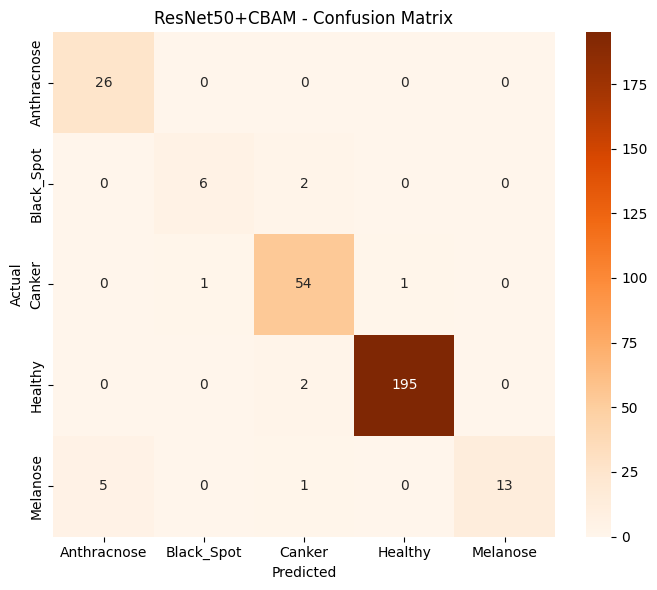

In [5]:
test_gen_resnet.reset()
test_loss_r, test_acc_r = model_resnet_cbam.evaluate(test_gen_resnet)
print(f"\nResNet50+CBAM Test Accuracy: {test_acc_r:.4f}")

test_gen_resnet.reset()
y_pred_probs_r = model_resnet_cbam.predict(test_gen_resnet)
y_pred_r = np.argmax(y_pred_probs_r, axis=1)
y_true_r = test_gen_resnet.classes
class_names = list(test_gen_resnet.class_indices.keys())

print("\nClassification Report (ResNet50+CBAM):")
print(classification_report(y_true_r, y_pred_r, target_names=class_names))

cm_r = confusion_matrix(y_true_r, y_pred_r)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_r, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("ResNet50+CBAM - Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/citrus_project/resnet50_cbam_confusion_matrix.png")
plt.show()

### 6. Fine-tune — unfreeze top layers of ResNet50, train at a low learning rate

In [6]:
base_model_resnet.trainable = True
for layer in base_model_resnet.layers[:-30]:
    layer.trainable = False

model_resnet_cbam.compile(optimizer=Adam(learning_rate=1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

callbacks_finetune = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ModelCheckpoint(
        "/content/drive/MyDrive/citrus_project/resnet50_cbam_finetuned_best.keras",
        monitor="val_accuracy", save_best_only=True
    ),
]

history_resnet_finetune = model_resnet_cbam.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.8203 - loss: 0.3555 - val_accuracy: 0.9664 - val_loss: 0.0936
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 812ms/step - accuracy: 0.9275 - loss: 0.1750 - val_accuracy: 0.9732 - val_loss: 0.0786
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 45s 790ms/step - accuracy: 0.9473 - loss: 0.1296 - val_accuracy: 0.9799 - val_loss: 0.0730
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 771ms/step - accuracy: 0.9687 - loss: 0.1040 - val_accuracy: 0.9765 - val_loss: 0.0710
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 683ms/step - accuracy: 0.9654 - loss: 0.0970 - val_accuracy: 0.9765 - val_loss: 0.0720
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 39s 678ms/step - accuracy: 0.9687 - loss: 0.0756 - val_accuracy: 0.9732 - val_loss: 0.0746
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 38s 661ms/step - accuracy: 0.9808 - loss: 0.0656 - val_accuracy: 0.9765 - val_loss: 0.0725
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 40s 696ms/step - accuracy: 0.9797 - loss: 0.0603 - val_accurac

### 7. Evaluate the fine-tuned model

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 501ms/step - accuracy: 0.9673 - loss: 0.0959

ResNet50+CBAM (fine-tuned) Test Accuracy: 0.9673
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 687ms/step

Classification Report (ResNet50+CBAM, fine-tuned):
              precision    recall  f1-score   support

 Anthracnose       0.92      0.92      0.92        26
  Black_Spot       0.75      0.75      0.75         8
      Canker       0.92      0.98      0.95        56
     Healthy       1.00      0.99      1.00       197
    Melanose       0.94      0.79      0.86        19

    accuracy                           0.97       306
   macro avg       0.91      0.89      0.90       306
weighted avg       0.97      0.97      0.97       306



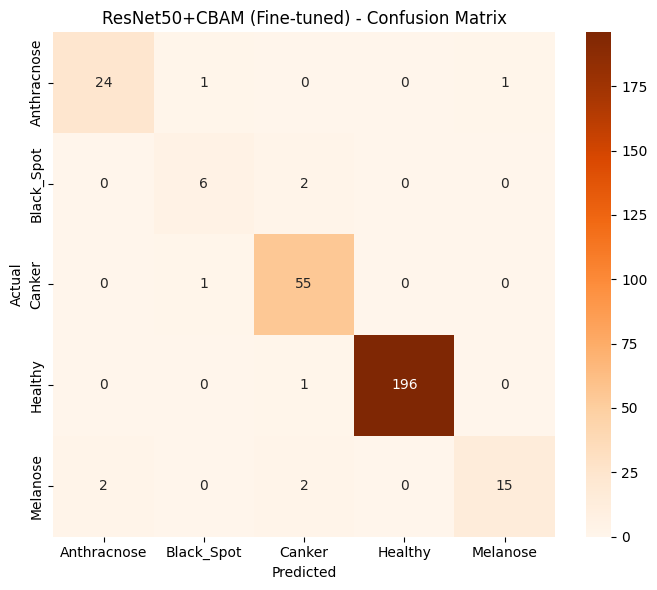

In [7]:
test_gen_resnet.reset()
test_loss_ft, test_acc_ft = model_resnet_cbam.evaluate(test_gen_resnet)
print(f"\nResNet50+CBAM (fine-tuned) Test Accuracy: {test_acc_ft:.4f}")

test_gen_resnet.reset()
y_pred_probs_ft = model_resnet_cbam.predict(test_gen_resnet)
y_pred_ft = np.argmax(y_pred_probs_ft, axis=1)
y_true_ft = test_gen_resnet.classes
class_names = list(test_gen_resnet.class_indices.keys())

print("\nClassification Report (ResNet50+CBAM, fine-tuned):")
print(classification_report(y_true_ft, y_pred_ft, target_names=class_names))

cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_ft, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("ResNet50+CBAM (Fine-tuned) - Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/citrus_project/resnet50_cbam_finetuned_confusion_matrix.png")
plt.show()

Upload a citrus leaf image:


Saving b_3.jpeg to b_3.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


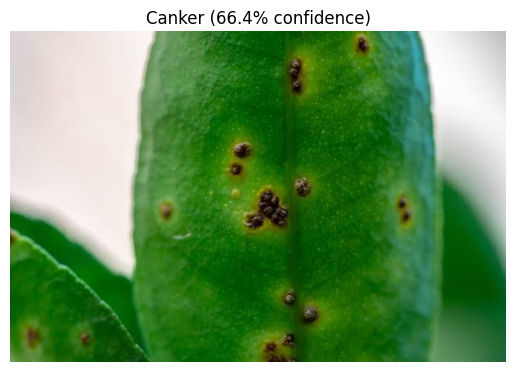


Prediction: Canker
Confidence: 66.42%

All class probabilities:
  Anthracnose : 33.58%
  Black_Spot  : 0.00%
  Canker      : 66.42%
  Healthy     : 0.00%
  Melanose    : 0.00%


In [11]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

class_names = list(test_gen_resnet.class_indices.keys())  # ['Anthracnose', 'Black_Spot', 'Canker', 'Healthy', 'Melanose']

print("Upload a citrus leaf image:")
uploaded = files.upload()

for fname in uploaded.keys():
    img = image.load_img(fname, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = resnet_preprocess(img_array)  # same preprocessing used in training

    preds = model_resnet_cbam.predict(img_array)
    predicted_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100

    plt.imshow(image.load_img(fname))
    plt.axis("off")
    plt.title(f"{predicted_class} ({confidence:.1f}% confidence)")
    plt.show()

    print(f"\nPrediction: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    print("\nAll class probabilities:")
    for cname, prob in zip(class_names, preds[0]):
        print(f"  {cname:12s}: {prob*100:.2f}%")

In [12]:
import os
import random

class_names = list(test_gen_resnet.class_indices.keys())
SPLIT_DIR = "/content/drive/MyDrive/citrus_project/split_dataset"

def predict_and_show(img_path, true_label):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = resnet_preprocess(img_array)

    preds = model_resnet_cbam.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100

    correct = "✓" if predicted_class == true_label else "✗"
    print(f"{correct} True: {true_label:12s} | Predicted: {predicted_class:12s} | Confidence: {confidence:.1f}%")


# Pull a few random images from the TEST set for Black_Spot and Melanose specifically
for cname in ["Black_Spot", "Melanose"]:
    folder = os.path.join(SPLIT_DIR, "test", cname)
    files_in_folder = os.listdir(folder)
    sample_files = random.sample(files_in_folder, min(4, len(files_in_folder)))

    print(f"\n--- {cname} test images ---")
    for f in sample_files:
        predict_and_show(os.path.join(folder, f), cname)


--- Black_Spot test images ---
✓ True: Black_Spot   | Predicted: Black_Spot   | Confidence: 100.0%
✓ True: Black_Spot   | Predicted: Black_Spot   | Confidence: 99.7%
✓ True: Black_Spot   | Predicted: Black_Spot   | Confidence: 99.3%
✓ True: Black_Spot   | Predicted: Black_Spot   | Confidence: 99.5%

--- Melanose test images ---
✓ True: Melanose     | Predicted: Melanose     | Confidence: 99.9%
✓ True: Melanose     | Predicted: Melanose     | Confidence: 56.8%
✓ True: Melanose     | Predicted: Melanose     | Confidence: 99.7%
✓ True: Melanose     | Predicted: Melanose     | Confidence: 99.7%


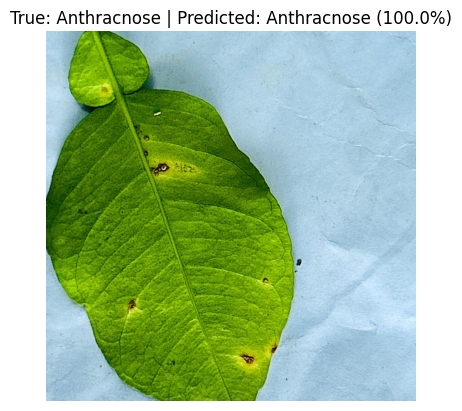

File: Anthracnose_00993.jpg
True label: Anthracnose
Predicted:  Anthracnose  (100.00% confidence)

All class probabilities:
  Anthracnose : 100.00%
  Black_Spot  : 0.00%
  Canker      : 0.00%
  Healthy     : 0.00%
  Melanose    : 0.00%


In [14]:
import os
import random
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

class_names = list(test_gen_resnet.class_indices.keys())
SPLIT_DIR = "/content/drive/MyDrive/citrus_project/split_dataset"

def predict_test_image(class_name, index=None):
    folder = os.path.join(SPLIT_DIR, "test", class_name)
    files_in_folder = sorted(os.listdir(folder))

    if index is None:
        img_file = random.choice(files_in_folder)
    else:
        img_file = files_in_folder[index]

    img_path = os.path.join(folder, img_file)

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = resnet_preprocess(img_array)

    preds = model_resnet_cbam.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100

    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.title(f"True: {class_name} | Predicted: {predicted_class} ({confidence:.1f}%)")
    plt.show()

    print(f"File: {img_file}")
    print(f"True label: {class_name}")
    print(f"Predicted:  {predicted_class}  ({confidence:.2f}% confidence)")
    print("\nAll class probabilities:")
    for cname, prob in zip(class_names, preds[0]):
        print(f"  {cname:12s}: {prob*100:.2f}%")


# ------- EDIT THESE TWO LINES TO CHOOSE WHAT TO PREDICT -------
CLASS_TO_TEST = "Anthracnose"   # options: Anthracnose, Black_Spot, Canker, Healthy, Melanose
IMAGE_INDEX = 0                 # 0, 1, 2... or set to None for a random pick
# ----------------------------------------------------------------

predict_test_image(CLASS_TO_TEST, IMAGE_INDEX)

In [15]:
import os

SPLIT_DIR = "/content/drive/MyDrive/citrus_project/split_dataset"

total_all = 0
for split in ["train", "val", "test"]:
    split_path = os.path.join(SPLIT_DIR, split)
    print(f"\n--- {split.upper()} ---")
    split_total = 0
    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        count = len(os.listdir(class_path))
        split_total += count
        print(f"  {class_name:12s}: {count}")
    print(f"  {'TOTAL':12s}: {split_total}")
    total_all += split_total

print(f"\n=== GRAND TOTAL across train+val+test: {total_all} ===")


--- TRAIN ---
  Anthracnose : 203
  Black_Spot  : 53
  Canker      : 446
  Healthy     : 976
  Melanose    : 142
  TOTAL       : 1820

--- VAL ---
  Anthracnose : 25
  Black_Spot  : 6
  Canker      : 55
  Healthy     : 195
  Melanose    : 17
  TOTAL       : 298

--- TEST ---
  Anthracnose : 26
  Black_Spot  : 8
  Canker      : 56
  Healthy     : 197
  Melanose    : 19
  TOTAL       : 306

=== GRAND TOTAL across train+val+test: 2424 ===
